In [1]:
import polars as pl
import pandas as pd
import numpy as np
import json
from catboost import CatBoostClassifier, Pool
from tqdm import tqdm

MERENI_PATH = r"E:\CVUT_BAP\kod\data\processed\mereni_model_raw.parquet"
PROHLIDKY_PATH = r"E:\CVUT_BAP\kod\data\processed\prohlidky_model.parquet"
MODEL_PATH = "model.bin"
SPLITS_PATH = "data_splits.json"
FEATURES_PATH = "features.json"
CAT_FEATURES_PATH = "cat_features.json"
TARGET_COL = 'Vysledek_Pristi'
OUTPUT_PREDICTIONS = "test_predictions.parquet"

with open(SPLITS_PATH, 'r') as f:
    test_ids = json.load(f).get('test_indices', [])
with open(FEATURES_PATH, 'r') as f:
    features = json.load(f)
with open(CAT_FEATURES_PATH, 'r') as f:
    cat_features = json.load(f)

active_cat_features = [c for c in cat_features if c in features]
num_features = [c for c in features if c not in active_cat_features]

print("Načítání a transformace dat přes Polars...")
lf_prohlidky = pl.scan_parquet(PROHLIDKY_PATH)
lf_mereni = pl.scan_parquet(MERENI_PATH)
df = lf_prohlidky.join(lf_mereni, on='CisloProtokolu', how='inner').collect()

df = df.with_columns([
    pl.col(c).cast(pl.Float32) for c in num_features if c in df.columns
]).with_columns([
    pl.col(c).cast(pl.String).fill_null("missing") for c in active_cat_features if c in df.columns
]).with_columns(
    (1 - pl.col(TARGET_COL)).cast(pl.Int8).alias(TARGET_COL)
)

print("Konverze na Pandas a filtrace testovací sady...")
df_pd = df.to_pandas()

test_indices = [int(i) for i in test_ids]
valid_indices = [i for i in test_indices if i < len(df_pd)]
df_test = df_pd.iloc[valid_indices].copy()

if len(df_test) == 0:
    print("CHYBA: Testovací sada je prázdná.")
    exit()

model = CatBoostClassifier()
model.load_model(MODEL_PATH)

chunk_size = 10000 
probabilities = []

for i in tqdm(range(0, len(df_test), chunk_size), desc="Inference"):
    chunk = df_test.iloc[i:i+chunk_size]
    
    inference_pool = Pool(
        data=chunk[features], 
        cat_features=active_cat_features
    )
    
    probs = model.predict_proba(inference_pool)[:, 1]
    probabilities.extend(probs)

df_test['prob_fail'] = probabilities

print(f"Export surových predikcí do {OUTPUT_PREDICTIONS}...")
df_export = df_test[['CisloProtokolu', TARGET_COL, 'prob_fail']]
df_export.to_parquet(OUTPUT_PREDICTIONS, index=False)

print("Hotovo.")

Načítání a transformace dat přes Polars...
Konverze na Pandas a filtrace testovací sady...


Inference: 100%|██████████| 98/98 [02:00<00:00,  1.23s/it]


Export surových predikcí do test_predictions.parquet...
Hotovo.


In [2]:
df_export

,CisloProtokolu,Vysledek_Pristi,prob_fail
4965667,CZ-410445-23-03-0333,0,0.357267
1017037,CZ-420119-19-07-0479,0,0.137671
5465511,CZ-481022-23-12-0112,0,0.423949
669730,CZ-450602-24-02-0619,0,0.696513
5280842,CZ-471221-23-07-0147,0,0.528015
...,...,...,...
931715,CZ-570711-21-09-0491,0,0.664390
5968625,CZ-430831-22-07-0569,0,0.406778
3596208,CZ-420930-19-10-0086,0,0.534589
4786412,CZ-410404-23-02-0220,0,0.661996


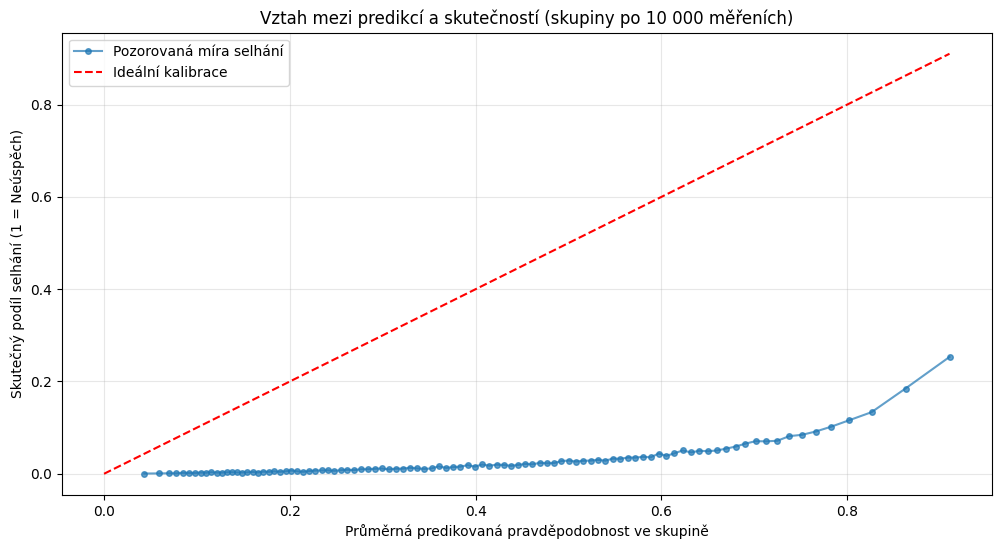

Top 5 nejrizikovějších skupin (průměry):
       prob_fail  actual_fail_rate
group                             
93      0.782815          0.102000
94      0.802247          0.116000
95      0.826326          0.133500
96      0.862896          0.184800
97      0.910252          0.253209


In [5]:
import matplotlib.pyplot as plt

# Seřazení podle predikované pravděpodobnosti
df_sorted = df_test.sort_values('prob_fail').reset_index(drop=True)

# Vytvoření skupin po 10 000 záznamech
df_sorted['group'] = df_sorted.index // 10000

# Agregace: průměrná predikce vs. skutečná míra selhání
vis_df = df_sorted.groupby('group').agg({
    'prob_fail': 'mean',
    TARGET_COL: 'mean'
}).rename(columns={TARGET_COL: 'actual_fail_rate'})

# Vykreslení kalibračního grafu
plt.figure(figsize=(12, 6))
plt.plot(vis_df['prob_fail'], vis_df['actual_fail_rate'], marker='o', markersize=4, linestyle='-', alpha=0.7, label='Pozorovaná míra selhání')
plt.plot([0, vis_df['prob_fail'].max()], [0, vis_df['prob_fail'].max()], color='red', linestyle='--', label='Ideální kalibrace')

plt.xlabel('Průměrná predikovaná pravděpodobnost ve skupině')
plt.ylabel('Skutečný podíl selhání (1 = Neúspěch)')
plt.title('Vztah mezi predikcí a skutečností (skupiny po 10 000 měřeních)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Výpis extrémních hodnot pro kontrolu
print("Top 5 nejrizikovějších skupin (průměry):")
print(vis_df.tail(5))

In [6]:
import pandas as pd
import numpy as np

df = pd.read_parquet("test_predictions.parquet")
df = df.sort_values('prob_fail').reset_index(drop=True)
target_col = 'Vysledek_Pristi'

# Cílové "hezké" hodnoty průměrné chybovosti pro první 3 skupiny.
# Čtvrtá (kritická) skupina absorbuje zbytek distribuce s maximálním rizikem.
target_rates = [0.005, 0.02, 0.05] 

thresholds = [0.0]
current_idx = 0
step = 5000

for target in target_rates:
    best_diff = float('inf')
    best_idx = current_idx + step
    
    # Heuristické hledání bodu řezu pro dosažení cílového průměru
    for i in range(current_idx + step, len(df), step):
        subset_mean = df[target_col].iloc[current_idx:i].mean()
        diff = abs(subset_mean - target)
        
        if diff < best_diff:
            best_diff = diff
            best_idx = i
            
        if subset_mean > target + 0.002:
            break
            
    thresholds.append(df['prob_fail'].iloc[best_idx])
    current_idx = best_idx

thresholds.append(1.0)

df['category'] = pd.cut(df['prob_fail'], bins=thresholds, labels=[1, 2, 3, 4], include_lowest=True)

summary = []
for i in range(1, 5):
    group = df[df['category'] == i]
    summary.append({
        "Skupina": i,
        "Dolni_Prah_Prob": float(thresholds[i-1]),
        "Horni_Prah_Prob": float(thresholds[i]),
        "Skutecna_Chybovost": float(group[target_col].mean()),
        "Pocet_Zaznamu": len(group)
    })

results_df = pd.DataFrame(summary)

pd.options.display.float_format = '{:.6f}'.format
print("\n--- Definice hranic pro dosažení cílových průměrů ---")
print(results_df.to_string(index=False))

results_df.to_csv("optimalizovane_prahy.csv", index=False)


--- Definice hranic pro dosažení cílových průměrů ---
 Skupina  Dolni_Prah_Prob  Horni_Prah_Prob  Skutecna_Chybovost  Pocet_Zaznamu
       1         0.000000         0.317829            0.004971         410001
       2         0.317829         0.547804            0.019963         295000
       3         0.547804         0.737719            0.049955         200000
       4         0.737719         1.000000            0.119062          66713
